In [4]:
import numpy as np
import matplotlib.pyplot as plt
import librosa
import soundfile as sf

print("Loading audio files...")
y_orig, sr_orig = librosa.load('../data/audio/the-weekend-star-boy.mp3', sr=None)
y_noisy, sr_noisy = librosa.load('../data/audio/the-weekend-star-boy-noisy.wav', sr=None)

print(f"Original Audio - Sample Rate: {sr_orig}Hz, Length: {len(y_orig)} samples")
print(f"Noisy Audio    - Sample Rate: {sr_noisy}Hz, Length: {len(y_noisy)} samples")

Loading audio files...
Original Audio - Sample Rate: 44100Hz, Length: 10164143 samples
Noisy Audio    - Sample Rate: 44100Hz, Length: 10164143 samples


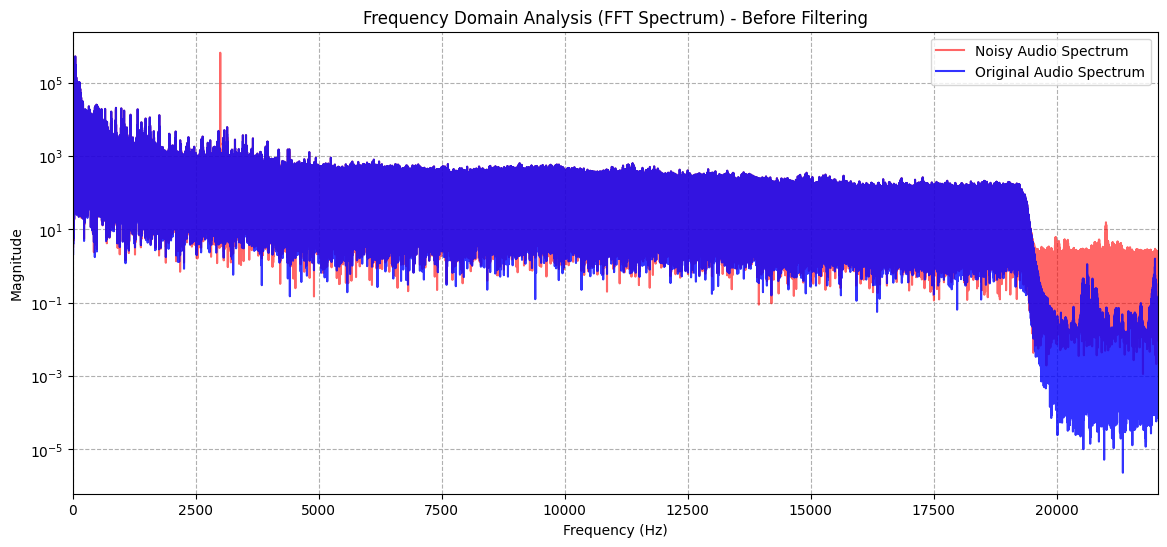

In [ ]:
n_samples = len(y_noisy)
fft_noisy = np.fft.fft(y_noisy)
fft_orig = np.fft.fft(y_orig[:n_samples])

frequencies = np.fft.fftfreq(n_samples, d=1/sr_noisy)

half_n = n_samples // 2
freq_plot = frequencies[:half_n]
amplitude_orig = np.abs(fft_orig[:half_n])
amplitude_noisy = np.abs(fft_noisy[:half_n])

plt.figure(figsize=(14, 6))
plt.plot(freq_plot, amplitude_noisy, color='red', alpha=0.6, label='Noisy Audio Spectrum')
plt.plot(freq_plot, amplitude_orig, color='blue', alpha=0.8, label='Original Audio Spectrum')
plt.title("Frequency Domain Analysis (FFT Spectrum) - Before Filtering")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.xlim(0, sr_noisy / 2)
plt.yscale('log')
plt.grid(True, which="both", ls="--")
plt.legend()
plt.show()

In [11]:
fft_clean = fft_noisy.copy()

frequencies = np.fft.fftfreq(len(y_noisy), d=1/sr_noisy)

for i, f in enumerate(frequencies):
    if (2950 <= abs(f) <= 3050):
        if np.abs(fft_clean[i]) > 10000: 
            fft_clean[i] = 0

fft_clean[np.abs(frequencies) > 19500] = 0

y_clean = np.fft.ifft(fft_clean)
y_clean = np.real(y_clean)

sf.write('../data/audio/the-weekend-star-boy-clean.wav', y_clean, sr_noisy)
print("Denoising hoàn tất với bộ lọc nhắm mục tiêu!")

Denoising hoàn tất với bộ lọc nhắm mục tiêu!


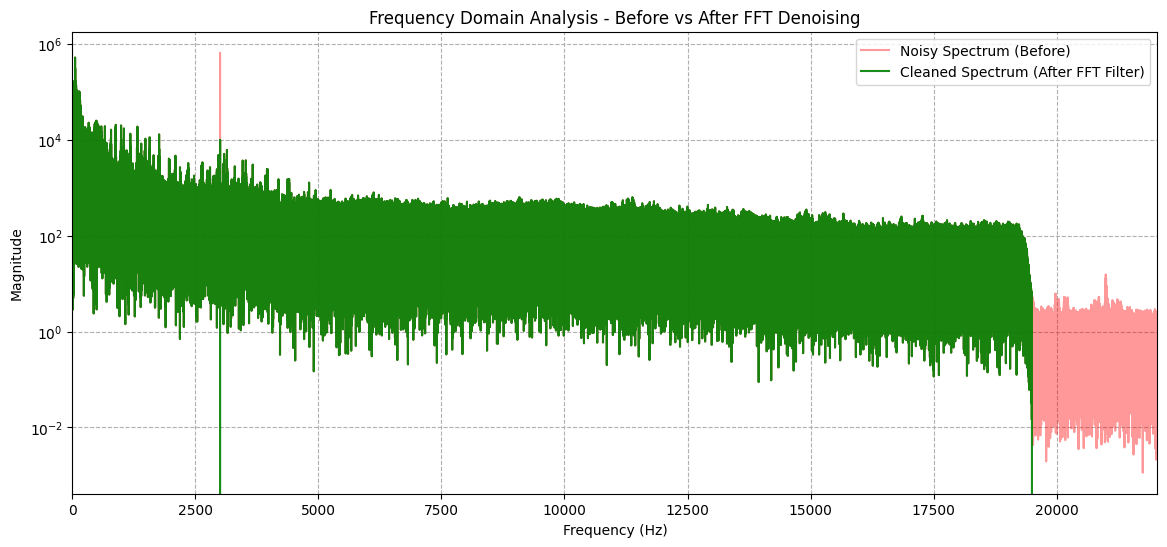

In [12]:
amplitude_clean = np.abs(fft_clean[:half_n])

plt.figure(figsize=(14, 6))
plt.plot(freq_plot, amplitude_noisy, color='red', alpha=0.4, label='Noisy Spectrum (Before)')
plt.plot(freq_plot, amplitude_clean, color='green', alpha=0.9, label='Cleaned Spectrum (After FFT Filter)')
plt.title("Frequency Domain Analysis - Before vs After FFT Denoising")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.xlim(0, sr_noisy / 2)
plt.yscale('log')
plt.grid(True, which="both", ls="--")
plt.legend()
plt.show()

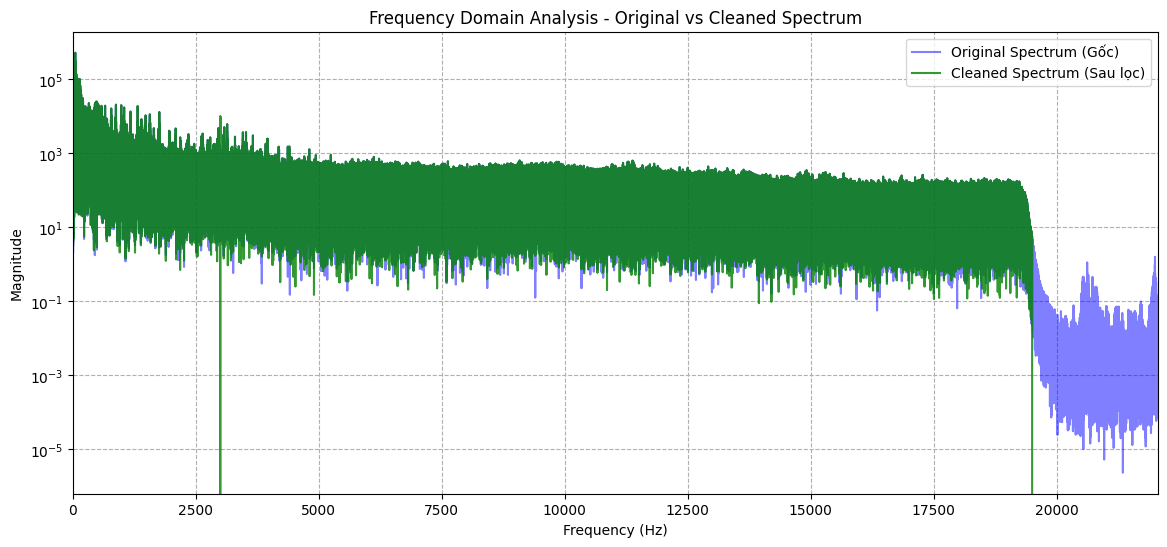

In [ ]:
amplitude_orig = np.abs(fft_orig[:half_n])
amplitude_clean = np.abs(fft_clean[:half_n])

plt.figure(figsize=(14, 6))
plt.plot(freq_plot, amplitude_orig, color='blue', alpha=0.5, label='Original Spectrum (Gốc)')
plt.plot(freq_plot, amplitude_clean, color='green', alpha=0.8, label='Cleaned Spectrum (Sau lọc)')

plt.title("Frequency Domain Analysis - Original vs Cleaned Spectrum")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.xlim(0, sr_noisy / 2)
plt.yscale('log') 
plt.grid(True, which="both", ls="--")
plt.legend()
plt.show()